# Table of Contents

1. [Data Loading](#1.-data-loading)
2. [Inferential Comparison of Continuous Variables](#2.-Inferential-Comparison-of-Continuous-Variables)
3. [Inferential Comparison of Categorical Variables](#3.-inferential-comparison-of-categorcial-variables)
4. [Multicollinearity variables](#4.-Multicollinearity-variables)


In [1]:
import warnings
warnings.filterwarnings("ignore")

# Sytem
import sys
from pathlib import Path

# Data cleaning
from ucimlrepo import fetch_ucirepo
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

#Test
import scipy.stats as stats
from scipy.stats import mannwhitneyu
from cliffs_delta import cliffs_delta
from statsmodels.stats.contingency_tables import Table2x2
from statsmodels.stats.multitest import multipletests


#Custome
sys.path.append(str(Path.cwd().parent / "src"))
from clinical_risk.inference import (rank_biserial,
                                    categorical_test,
compute_vif)
from clinical_risk.plotting import plot_categorical_effects,plot_numeric_effects
#options
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

# 1. Data Loading

In [2]:
# Load data
data = fetch_ucirepo(id=519)
df = pd.concat([data.data.targets, data.data.features ], axis=1)

target_col = "death_event"
binary_cols = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking", "death_event"]
numeric_cols = [col for col in df.columns if col not in binary_cols]
categorical_vars = [i for i in binary_cols if i!="death_event"]

group0 = df[df[target_col] == 0].copy()
group1 = df[df[target_col] == 1].copy()




print("Shape:", df.shape)
print("Grupo 0 (no death):", group0.shape[0])
print("Grupo 1 (death):", group1.shape[0])

Shape: (299, 13)
Grupo 0 (no death): 203
Grupo 1 (death): 96


# 2. Inferential Comparison of Continuous Variables

In [3]:
numeric_results = []

for col in numeric_cols:
    x0, x1 = group0[col].dropna(), group1[col].dropna()
    u, p = stats.mannwhitneyu(x0, x1, alternative="two-sided")
    delta, mag = cliffs_delta(x1, x0)

    numeric_results.append({
        "variable": col,
        "group0_mean": x0.mean(),
        "group1_mean": x1.mean(),
        "group0_median": x0.median(),
        "group1_median": x1.median(),
        "median_diff_g1_minus_g0": x1.median() - x0.median(),
        "mannwhitney_u": u,
        "p_value": p,
        "rank_biserial": rank_biserial(u, len(x0), len(x1)),
        "cliffs_delta": delta,
        "cliffs_magnitude": mag
    })

numeric_results_df = pd.DataFrame(numeric_results).sort_values("p_value")
numeric_results_df["p_adj_fdr"] = multipletests(numeric_results_df["p_value"], method="fdr_bh"
)[1]


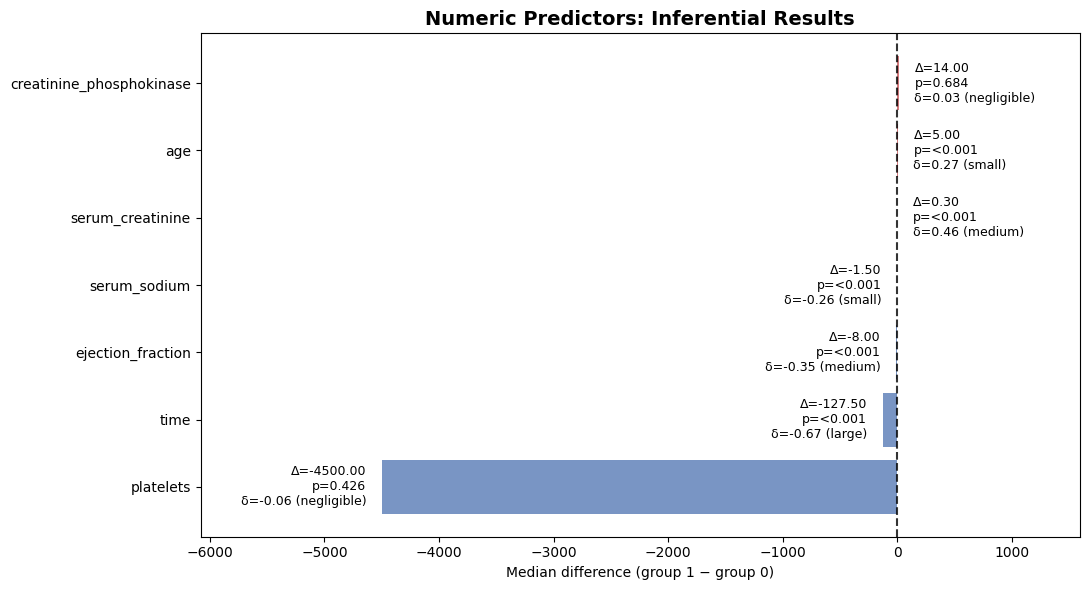

In [4]:
plot_numeric_effects(numeric_results_df)

# 3. Inferential Comparison of Categorical Variables

In [5]:
categorical_results = []

for col in categorical_vars:
    table = pd.crosstab(df[col], df[target_col])

    # Ensure 2x2 with rows/cols ordered
    table = table.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
    test_result = categorical_test(table)
    
    # proportions
    death_rate_if_0 = table.loc[0, 1] / table.loc[0].sum() if table.loc[0].sum() > 0 else np.nan
    death_rate_if_1 = table.loc[1, 1] / table.loc[1].sum() if table.loc[1].sum() > 0 else np.nan
    
    # odds ratio and CI from 2x2 table
    arr = table.values
    table2x2 = Table2x2(arr)
    
    or_value = table2x2.oddsratio
    ci_low, ci_high = table2x2.oddsratio_confint()
    
    categorical_results.append({
        "variable": col,
        "death_rate_if_0": death_rate_if_0,
        "death_rate_if_1": death_rate_if_1,
        "abs_diff": death_rate_if_1 - death_rate_if_0,
        "test_used": test_result["test"],
        "p_value": test_result["p_value"],
        "odds_ratio": or_value,
        "or_ci_low": ci_low,
        "or_ci_high": ci_high
    })

categorical_results_df = pd.DataFrame(categorical_results).sort_values("p_value")
categorical_results_df["p_adj_fdr"] = multipletests(categorical_results_df["p_value"], method="fdr_bh"
)[1]
categorical_results_df

,variable,death_rate_if_0,death_rate_if_1,abs_diff,test_used,p_value,odds_ratio,or_ci_low,or_ci_high,p_adj_fdr
2,high_blood_pressure,0.2938,0.3714,0.0776,Chi-square,0.1700,1.4203,0.8596,2.3466,0.6296
0,anaemia,0.2941,0.3566,0.0625,Chi-square,0.2518,1.3301,0.8161,2.1679,0.6296
4,smoking,0.3251,0.3125,-0.0126,Chi-square,0.8272,0.9435,0.5598,1.5902,0.9732
3,sex,0.3238,0.3196,-0.0042,Chi-square,0.9405,0.9808,0.5901,1.6303,0.9732
1,diabetes,0.3218,0.3200,-0.0018,Chi-square,0.9732,0.9916,0.6061,1.6224,0.9732


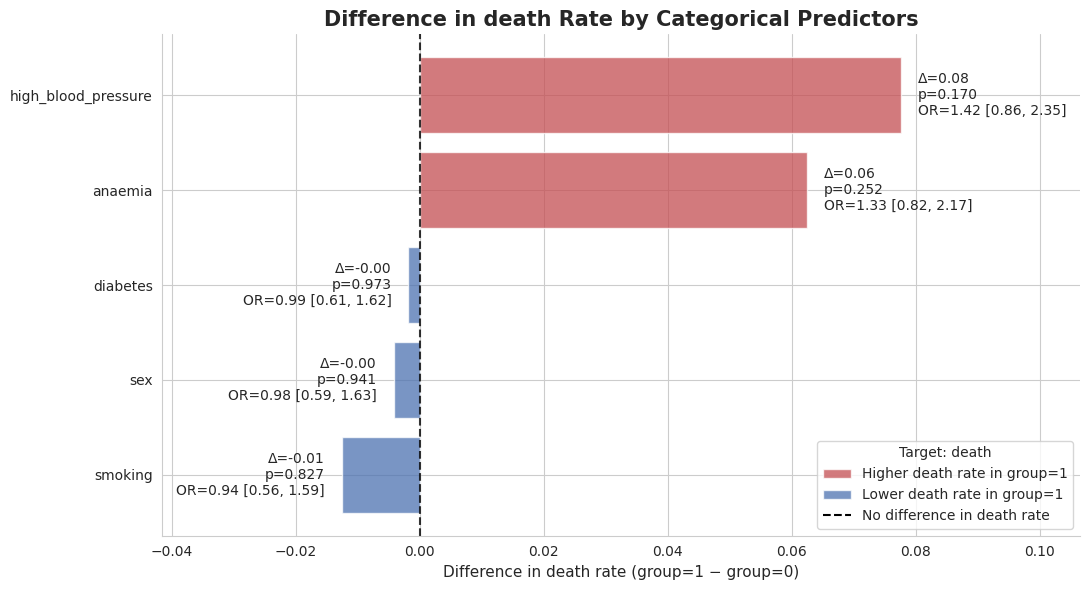

In [6]:
plot_categorical_effects(
    categorical_results_df,
    target_name="death",
    use_adjusted_p=False
)

# 4. Multicollinearity variables

In [7]:
vif = compute_vif(data.data.features)
vif

,variable,VIF
0,const,1087.8325
1,age,1.1061
2,anaemia,1.0872
3,creatinine_phosphokinase,1.0660
4,diabetes,1.0643
5,ejection_fraction,1.0678
6,high_blood_pressure,1.0684
7,platelets,1.0458
8,serum_creatinine,1.0812
9,serum_sodium,1.1019
